In [1]:
# Search of Sentinel-2's relevant patches, given the provided sites

In [9]:
from pystac_client import Client
import joblib
from typing import Any
import os
import geopandas as gpd
import requests
from pystac.item import Item as PySTACItem
from pystac_client.client import Client as PySTACClient
from datetime import date
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from shapely.geometry import box
import matplotlib.pyplot as plt
from datetime import datetime, timezone

In [2]:
from utils.constants import SENTINEL_SCENES_FOLDERPATH, SILVER_FOLDERPATH, EARCH_SEARCH_API_URL, SENTINEL_BANDS, GHANA_GDF
from utils.site import Site

client = Client.open(EARCH_SEARCH_API_URL)

In [3]:
# Load sites
sites = joblib.load(SILVER_FOLDERPATH / "sites.pkl")
print(f"Loaded {len(sites)} sites")

Loaded 155 sites


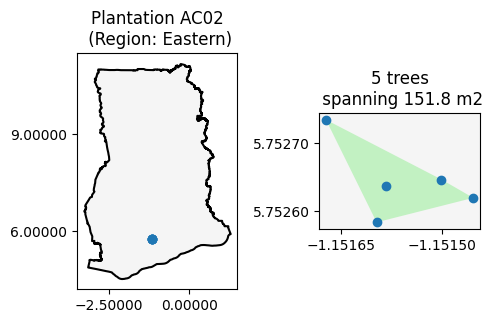

In [4]:
s = sites[1]
s.plot()

In [5]:
# Search for all Spatio-Temporal Asset Catalog item (Sentinel Patches)
# that contain forestero sites between 2018-2017
allowed_datetimes = [f"{yyyy}-01-01/{yyyy}-01-30" for yyyy in range(2018, 2027)]

def _search_stac(dt: str, bbox: tuple[float, float, float, float], client: PySTACClient) -> tuple[str, list[PySTACItem]]:
        """Helper function to run a single search."""
        search = client.search(
            collections=["sentinel-2-l2a"],
            bbox=bbox,
            datetime=dt,  # e.g. "2020-01-01/2021-01-30"
            query={"eo:cloud_cover": {"lt": 20}},
        )
        stac_items = list(search.items())
        return dt, stac_items

def search_stac(dts: list[str], bbox: tuple[float, float, float, float], client: PySTACClient) -> list[PySTACItem]:
    with ThreadPoolExecutor(max_workers=50) as executor:
        futures = {executor.submit(_search_stac, dt, bbox, client): dt for dt in dts}
    
        # Fetch futures
        all_stac_items = []
        for future in as_completed(futures):
            _, stac_items = future.result()
            all_stac_items.extend(stac_items)

    return all_stac_items

stac_item_id_to_stac_item = {}
for site in tqdm(sites, total=len(sites)):
    stac_items = search_stac(allowed_datetimes, site.bbox, client)
    for si in stac_items:
        stac_item_id_to_stac_item[si.id] = si

stac_items = list(stac_item_id_to_stac_item.values())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [03:35<00:00,  1.39s/it]


In [10]:
# Only consider the January 2020 STAC items
def is_within_datetimes(stac_item, min_dt: datetime, max_dt: datetime) -> bool:
    dt = datetime.fromisoformat(stac_item.properties["s2:generation_time"])
    if min_dt <= dt <= max_dt:
        return True

    return False

min_dt = datetime(2020, 1, 1, tzinfo=timezone.utc)
max_dt = datetime(2020, 2, 1, tzinfo=timezone.utc)
stac_items = [e for e in stac_items if is_within_datetimes(e, min_dt, max_dt)]

print(f"Kept {len(stac_items)} STAC items, all generated in january 2020")

bboxes = list(set([tuple(e.bbox) for e in stac_items]))
print(f"- Covering {len(bboxes)} unique bboxes.")

Kept 61 STAC items, all generated in january 2020
- Covering 48 unique bboxes.


In [11]:
# For each bbox, only keep the least cloudy STAC items
bbox_to_stac_item = {}
for si in stac_items:
    bbox = tuple(si.bbox)

    stac_item = bbox_to_stac_item.get(bbox)
    
    if stac_item is None:
        bbox_to_stac_item[bbox] = si
    elif si.properties["eo:cloud_cover"] < stac_item.properties["eo:cloud_cover"]:
        bbox_to_stac_item[bbox] = si    

stac_items = list(bbox_to_stac_item.values())
print(f"Kept {len(stac_items)} STAC items, each the least cloudy of jan. 2020")

bboxes = list(set([tuple(e.bbox) for e in stac_items]))
print(f"- Covering {len(bboxes)} unique bboxes.")

Kept 48 STAC items, each the least cloudy of jan. 2020
- Covering 48 unique bboxes.


Text(0.5, 1.0, 'Ghana with all (48) found STAC items')

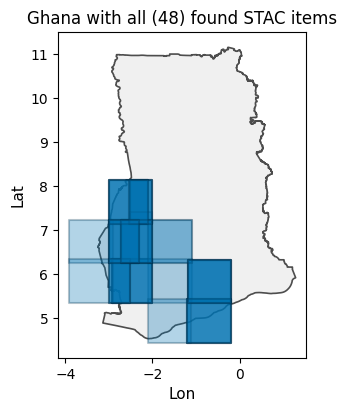

In [12]:
# Plot all found STAC items on Ghana, along with all sites locations

def plot_gdf(gdf: gpd.GeoDataFrame):
    # Plot base region
    gdf.plot(ax=plt.gca(), color="#f0f0f0", edgecolor="#4d4d4d", linewidth=1.2)
        
    plt.xlabel("Lon", fontsize=11)

    plt.ylabel("Lat", fontsize=11)

def plot_polygons(polygons: list[shapely.geometry.polygon.Polygon]) -> None:
    # Bounds -> gdf
    for p in polygons:
        bounds_gdf = gpd.GeoDataFrame({"geometry": [p]}, crs="epsg:4326")
        
        # Plot Sentinel patches as semi-transparent squares
        bounds_gdf.plot(ax=plt.gca(), color="#0072B2", edgecolor="#003554", alpha=0.3, linewidth=1.5)  
    
    plt.tight_layout()

# Convert the found patches into polygons
bboxes = list(set([tuple(e.bbox) for e in stac_items]))
polygons = [box(*e) for e in bboxes]

# Plot
fig = plt.figure(figsize=(4,4))
plot_gdf(GHANA_GDF)
plot_polygons(polygons)
plt.title(f"Ghana with all ({len(stac_items)}) found STAC items")

In [13]:
# Dump found stac_items
joblib.dump(stac_items, SILVER_FOLDERPATH / "stac_items.joblib")

['/home/aga/Documents/clients/forestero/skymap/skymap/data/silver/stac_items.joblib']